```
Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

In [ ]:
# If these are not available (e.g., colab), please uncomment the lines below.
# ! pip install infomeasure
# ! pip install pooch

import infomeasure as im
import pooch

In [ ]:
# DATASET TERMS OF SERVICE NOTICE
# The dataset used below is available at: https://doi.org/10.7910/DVN/0SGZFF
# It is downloaded here purely for convenience, as this specific analysis
# complies with its Terms of Service (ToS). For any other usage, or if you
# modify this notebook, you MUST visit the official link to review and accept
# the ToS. By executing this code, you acknowledge that you have read and
# accepted the dataset's Terms of Service.

survey_and_browser_attrs_fpath = pooch.retrieve(
    url='doi:10.7910/DVN/0SGZFF/survey-and-browser-attributes-data.csv',
    known_hash="md5:8f6db8be6551cc740c9a64d6c2bc8a8f"
)

In [ ]:
import pandas as pd

stable_ba_names = [
    'User agent', 'Languages', # Can be collected passively via HTTP headers
    'Timezone', 'Screen resolution',
    'Color depth', 'Platform', 'Touch points',
    'Hardware concurrency', 'Device memory',
    'WebGL Vendor', 'WebGL Unmasked Vendor',
    'WebGL Renderer', 'WebGL Unmasked Renderer',
]
# Replace nan values with the empty string
sba_df = pd.read_csv(survey_and_browser_attrs_fpath, usecols=['ResponseId']+stable_ba_names)
sba_df = sba_df.set_index('ResponseId').fillna('')
N = len(sba_df)
N

8400

In [ ]:
def get_unhashed_fingerprint(user_data):
  return ':'.join(pd.Series(user_data).values.astype(str).tolist())

def get_fingerprint(user_data):
  return hash(get_unhashed_fingerprint(user_data))

sba_df['Fingerprint'] = sba_df[stable_ba_names].apply(get_fingerprint, axis=1)

In [ ]:
from scipy.stats import entropy

# shannon entropy (standard measurement)
def get_shannon_entropy(values):
  pk = pd.Series(values).value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  H = entropy(pk, base=2) # unit is bits
  return H

def get_normalized_shannon_entropy(values):
  """Returns value H(X)/H_N where H_N represents worst case where all values are unique."""
  H_N = get_shannon_entropy(list(range(len(values))))
  return get_shannon_entropy(values)/H_N

def get_reid_score(values):
  pk = pd.Series(values).value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  return pk.pow(2).sum()

def get_tsallis_entropy(values):
  return 1 - get_reid_score(values)

def get_frac_unique(values):
  value_counts = values.value_counts()
  return round((value_counts == 1).sum()/len(values), 4)


test_attr = 'User agent'
values = sba_df[test_attr]
print('%0.3f = Shannon entropy for %s' % (get_shannon_entropy(values), test_attr))
print('%0.3f = Normalized Shannon entropy for %s' % (get_normalized_shannon_entropy(values), test_attr))

4.613 = Shannon entropy for User agent
0.354 = Normalized Shannon entropy for User agent


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import infomeasure as im
from scipy.stats import entropy
import concurrent.futures
import warnings

im.Config.set_log_level("ERROR")

# --- User-defined Estimators ---
def get_shannon_entropy(values):
  pk = pd.Series(values).value_counts() / len(values)
  return entropy(pk, base=2)

def get_normalized_shannon_entropy(values):
  H_N = np.log2(len(values))
  if H_N == 0: return 0
  return get_shannon_entropy(values) / H_N

def get_tsallis_entropy(values):
  pk = pd.Series(values).value_counts() / len(values)
  return 1 - (pk**2).sum()

def im_entropy(data, approach, **kwargs):
    """
    Wraps im.entropy to handle specific Bayesian priors by calculating alpha.

    Supported bayes approaches:
      - bayes_jeffreys: alpha = 0.5
      - bayes_laplace: alpha = 1.0
      - bayes_schurmann_grassberger: alpha = 1/K
      - bayes_minimax: alpha = sqrt(N)/K
    """
    # If the approach does not start with "bayes_", call im.entropy directly
    if not approach.startswith("bayes_"):
      with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return im.entropy(data, approach=approach, **kwargs)

    # Calculate N (sample size) and K (number of unique values in data)
    N = len(data)
    K = len(set(data))

    # Extract the prior name
    prior_name = approach.replace("bayes_", "")

    # Determine alpha based on the prior
    if prior_name == "jeffreys":
        # Jeffreys Prior (alpha = 0.5)
        alpha = 0.5
    elif prior_name == "laplace":
        # Laplace Prior (alpha = 1.0)
        alpha = 1.0
    elif prior_name == "schurmann_grassberger":
        # Schürmann-Grassberger Prior (alpha = 1/K)
        alpha = 1.0 / K
    elif prior_name == "minimax":
        # Minimax Prior (alpha = sqrt(N)/K)
        alpha = np.sqrt(N) / K
    else:
        raise ValueError(f"Unknown Bayesian prior type: {prior_name}")

    # Call im.entropy with the 'bayes' approach and the calculated alpha
    with warnings.catch_warnings():
      warnings.simplefilter("ignore")
      return im.entropy(data, approach="bayes", alpha=alpha, **kwargs)


# --- Configuration ---
attributes = [
    'User agent',
    'Fingerprint',
]
# "discrete" is the ML estimator, so it's the same as the "Shannon" line.
estimator_names = {
    "miller_madow": "Miller-Madow",
    "grassberger": "Grassberger",
    "shrink": "Shrinkage",
    "chao_shen": "Chao-Shen",
    "chao_wang_jost": "Chao-Wang-Jost",
    "bayes_jeffreys": "Bayesian (Jeffreys)",
    "bayes_laplace": "Bayesian (Laplace)",
    "bayes_schurmann_grassberger": "Bayesian (Schürmann-Grassberger)",
    "bayes_minimax": "Bayesian (Minimax)",
    "nsb": "NSB",
    "ansb": "ANSB",
    "zhang": "Zhang",
    "bonachela": "Bonachela",
}
estimators = [
    "miller_madow",
    "grassberger",
    "shrink",
    "chao_shen",
    "chao_wang_jost",
]
trials = 100
workers = 5
N = len(sba_df)
ns = [100] + list(range(200, N+1, 200))

# Colors
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
est_colors = {est: colors[i % len(colors)] for i, est in enumerate(estimators)}

# --- Helper Function for Parallelization ---
def run_trial(n, full_data, estimators):
  sample = list(full_data.sample(n=n, replace=False))

  # Current Estimators
  trial_res = {
    'Shannon Entropy': get_shannon_entropy(sample),
    'Normalized Shannon': get_normalized_shannon_entropy(sample),
    'Tsallis Entropy': get_tsallis_entropy(sample)
  }

  # Library Estimators
  for est in estimators:
    try:
      val = im_entropy(sample, approach=est, base=2)
    except:
      print(f'error {est}, {n}, {e}')
      val = np.nan

    trial_res[est] = val

  return trial_res

# --- Computation ---
print("Computing entropies (parallelized)... this may take a few minutes.")
attributes_entropy_data = {}

for attr in attributes:
  print(f"Processing {attr}...")
  full_data = sba_df[attr]

  # Initialize storage
  res = {est: [] for est in estimators}
  res['Shannon Entropy'] = []
  res['Normalized Shannon'] = []
  res['Tsallis Entropy'] = []
  res['n'] = ns

  for n in ns:
    trial_vals = {k: [] for k in res.keys() if k != 'n'}

    # Parallel Execution
    with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as exec:
      futures = [
          exec.submit(run_trial, n, full_data, estimators)
          for _ in range(1 if n == N else trials)]

      for future in concurrent.futures.as_completed(futures):
        try:
          r = future.result()
          for k, v in r.items():
              trial_vals[k].append(v)
        except Exception as e:
          print(f"Trial failed: {e}")

    # Averages over trials
    for k in trial_vals:
      res[k].append(np.nanmean(trial_vals[k]))

  df_res = pd.DataFrame(res).set_index('n')

  # --- Calculate Relative Errors ---
  for est in estimators + ['Shannon Entropy', 'Tsallis Entropy']:
    pop_est = df_res[est][N]
    df_res[f'{est}_error'] = (df_res[est] - pop_est).abs() / pop_est

  attributes_entropy_data[attr] = df_res

Computing entropies (parallelized)... this may take a few minutes.
Processing User agent...
Processing Fingerprint...


In [ ]:
def generate_plot(attributes_entropy_data, plot_attributes, logscale=False):

  # Create a 2x2 grid: 2 rows (Entropy, Error) and 2 columns
  fig, axes = plt.subplots(
      2, len(plot_attributes), figsize=(8.5, 8), dpi=200, squeeze=False)

  for j, a in enumerate(plot_attributes):
      data = attributes_entropy_data[a]

      # 1. Combined Shannon and Tsallis Entropy Plot (Top row)
      ax_shannon = axes[0][j]

      for est in estimators:
          ax_shannon.plot(
              data.index,
              data[est],
              linestyle='dashed',
              color=est_colors[est])

      ax_shannon.plot(data.index, data['Shannon Entropy'], color='black')

      # Add the names on top of the columns
      ax_shannon.set_title(a)

      # Only show the left y-axis label for the first column
      if j == 0:
          ax_shannon.set_ylabel('Shannon Entropy')
      else:
          ax_shannon.set_yticklabels([])

      ax_shannon.set_ylim(0, 15.7)
      ax_shannon.set_xlim(0, N*1.01)
      ax_shannon.grid(False)
      if logscale:
        ax_shannon.set_xscale('log')
        ax_shannon.set_xlim(100, 10000)

      # Change the x-labels to be every 2000
      ax_shannon.set_xticks(np.arange(0, N + 1, 2000))

      # Remove ticklabels from the top plots
      ax_shannon.tick_params(labelbottom=False)

      # Create twin axis for Tsallis Entropy
      ax_tsallis = ax_shannon.twinx()
      ax_tsallis.plot(
          data.index, data['Tsallis Entropy'], color='black', linestyle='-.')

      # Only show the right y-axis label for the last column
      if j == len(plot_attributes) - 1:
          ax_tsallis.set_ylabel('Tsallis Entropy')
      else:
          # Hide tick labels for the inner columns
          ax_tsallis.set_yticklabels([])

      ax_tsallis.set_ylim(0, 1.05)
      ax_tsallis.grid(False)
      if logscale:
        ax_tsallis.set_xscale('log')
        ax_tsallis.set_xlim(100, 10000)

      # 2. Relative Error Plot (Bottom row)
      ax_err = axes[1][j]
      for est in estimators:
          ax_err.plot(
              data.index,
              data[f'{est}_error'],
              linestyle='dashed',
              color=est_colors[est],
              label=estimator_names[est] if j == 0 else "_nolegend_")

      ax_err.plot(
          data.index,
          data['Shannon Entropy_error'],
          color='black',
          label='Shannon Entropy' if j == 0 else "_nolegend_")

      ax_err.plot(
          data.index,
          data['Tsallis Entropy_error'],
          color='black',
          linestyle='-.',
          label='Tsallis Entropy' if j == 0 else "_nolegend_")

      if j == 0:
          ax_err.set_ylabel('Entropy relative error')
      else:
          # Hide inner y-axis ticks for a cleaner grid appearance
          ax_err.set_yticklabels([])

      ax_err.set_ylim(-0.01, 0.4)
      ax_err.set_xlim(0, N*1.01)
      ax_err.grid(False)
      if logscale:
        ax_err.set_xscale('log')
        ax_err.set_xlim(100, 10000)

      # Keep xlabel on the bottom plots
      ax_err.set_xlabel('n')

  # Put legend in a single line dynamically based on the number of items
  num_legend_items = len(estimators) + 2
  fig.legend(
      loc='upper center',
      bbox_to_anchor=(0.5, 0.04),
      ncol=4,
      frameon=False,
      fontsize=12.5)

  # Adjust layout to make room for the bottom legend
  plt.tight_layout(rect=[0, 0.02, 1, 1])
  plt.show()

The cell below generates **Figure 7** of the paper: *Analysis from Figure 5 repeated using advanced Shannon entropy estimators, with comparisons to Tsallis entropy. Values are computed over increasing sample sizes, averaged over 100 trials. Left: User agent. Right: Overall “Fingerprint”. Top: Variation in mean entropy values. Bottom: Variation in relative error, computed as the difference between the mean estimate for the subsample versus population (N=8400).*

Generating plots...


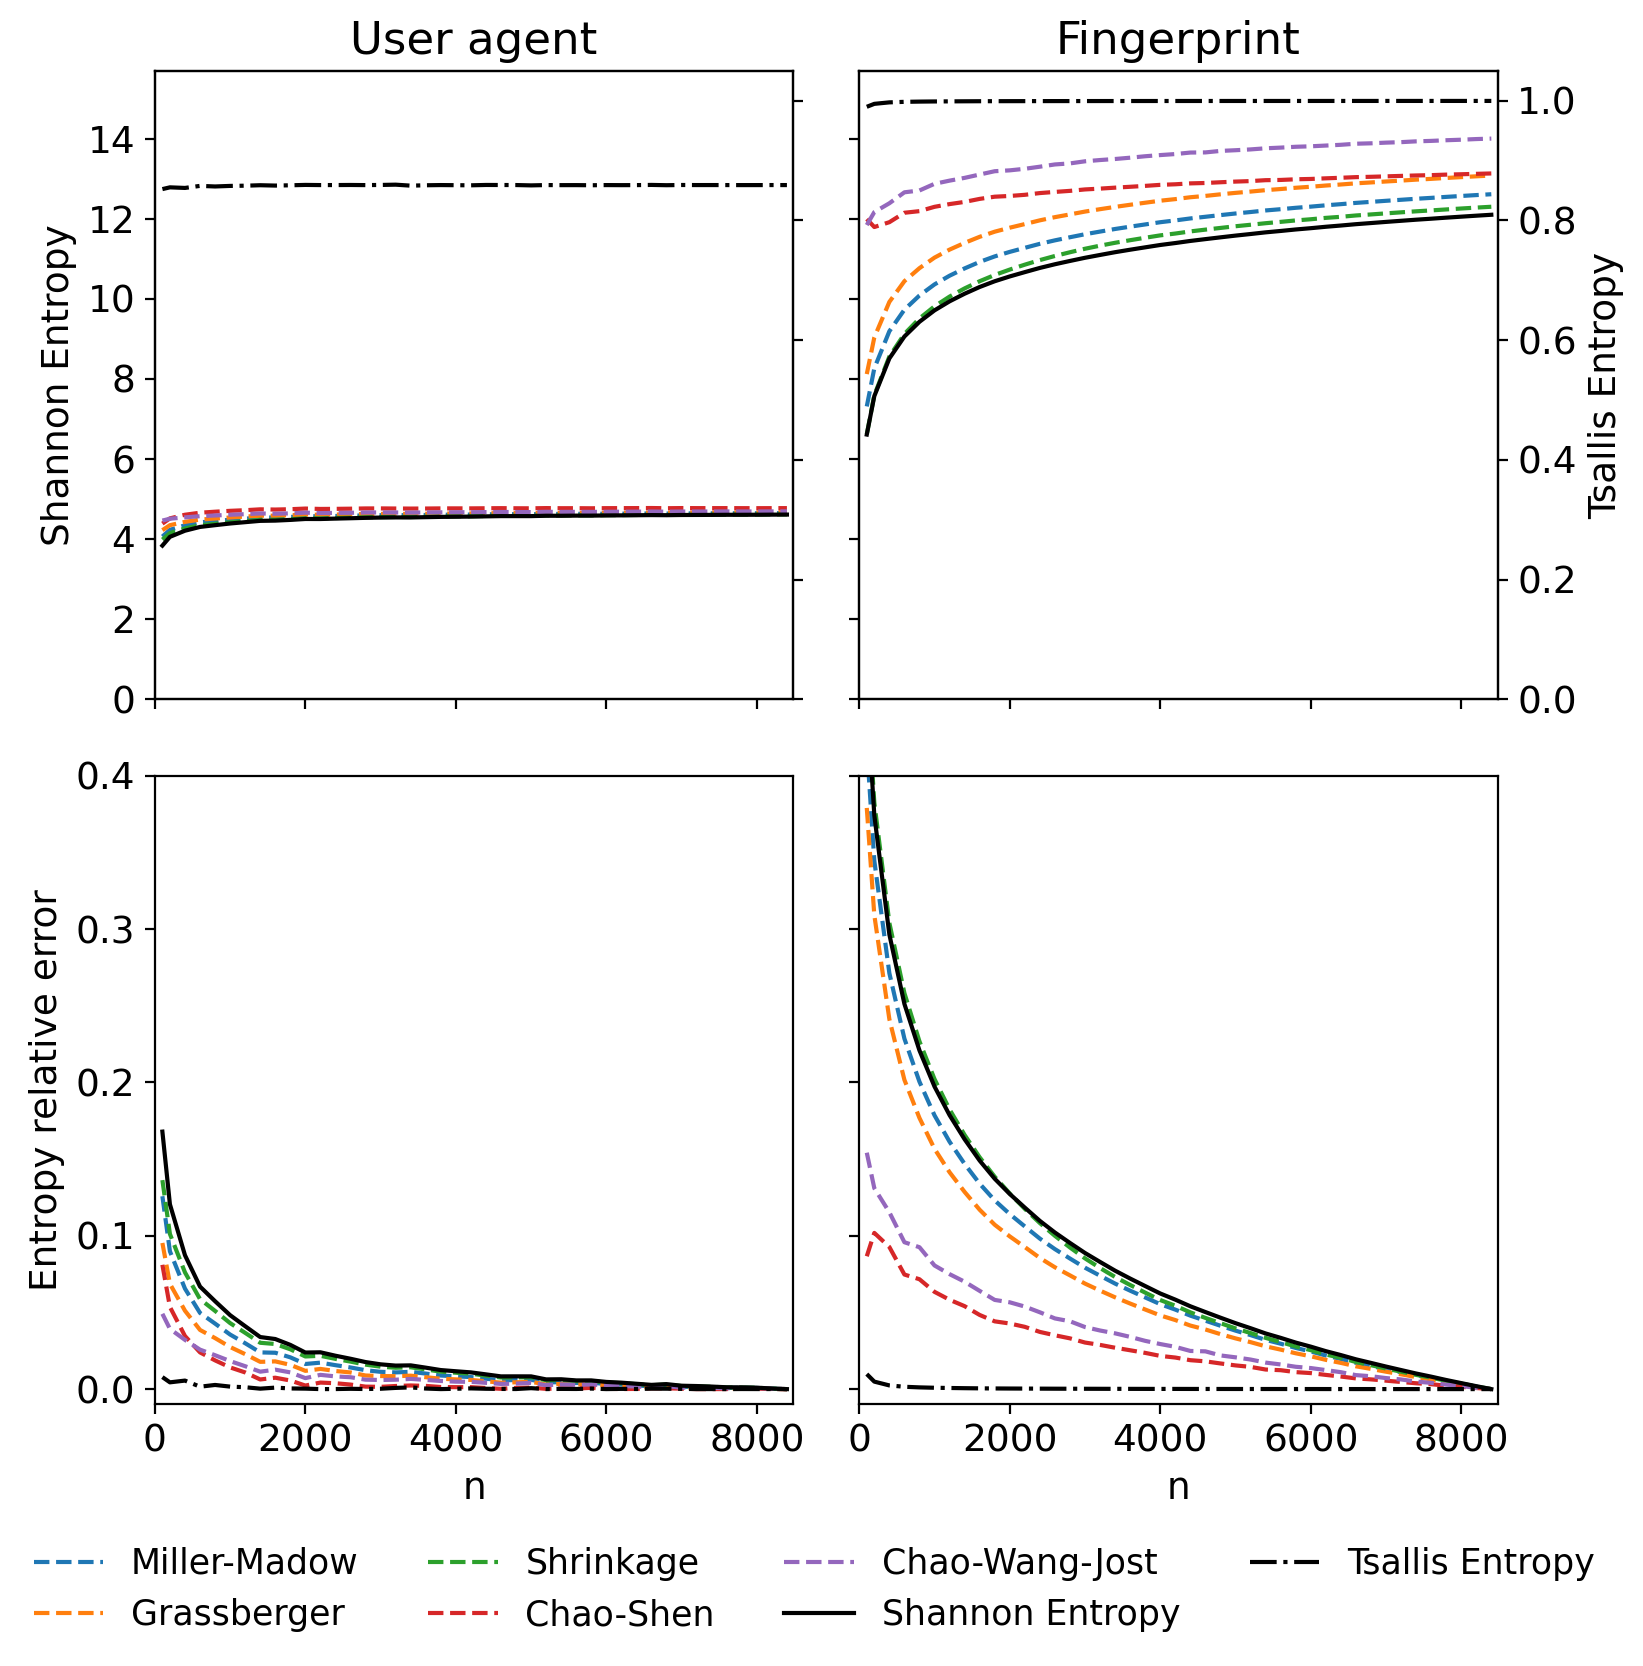

In [ ]:
# --- Plotting ---
print("Generating plots...")
plt.rcParams.update({'font.size': 13.5})

generate_plot(
    attributes_entropy_data,
    plot_attributes=['User agent', 'Fingerprint'],
    logscale=False
)

The cell below generates **Figure 10** of the paper (in Appendix E): *Figure 7 replicated with the x-axis on a log scale..*

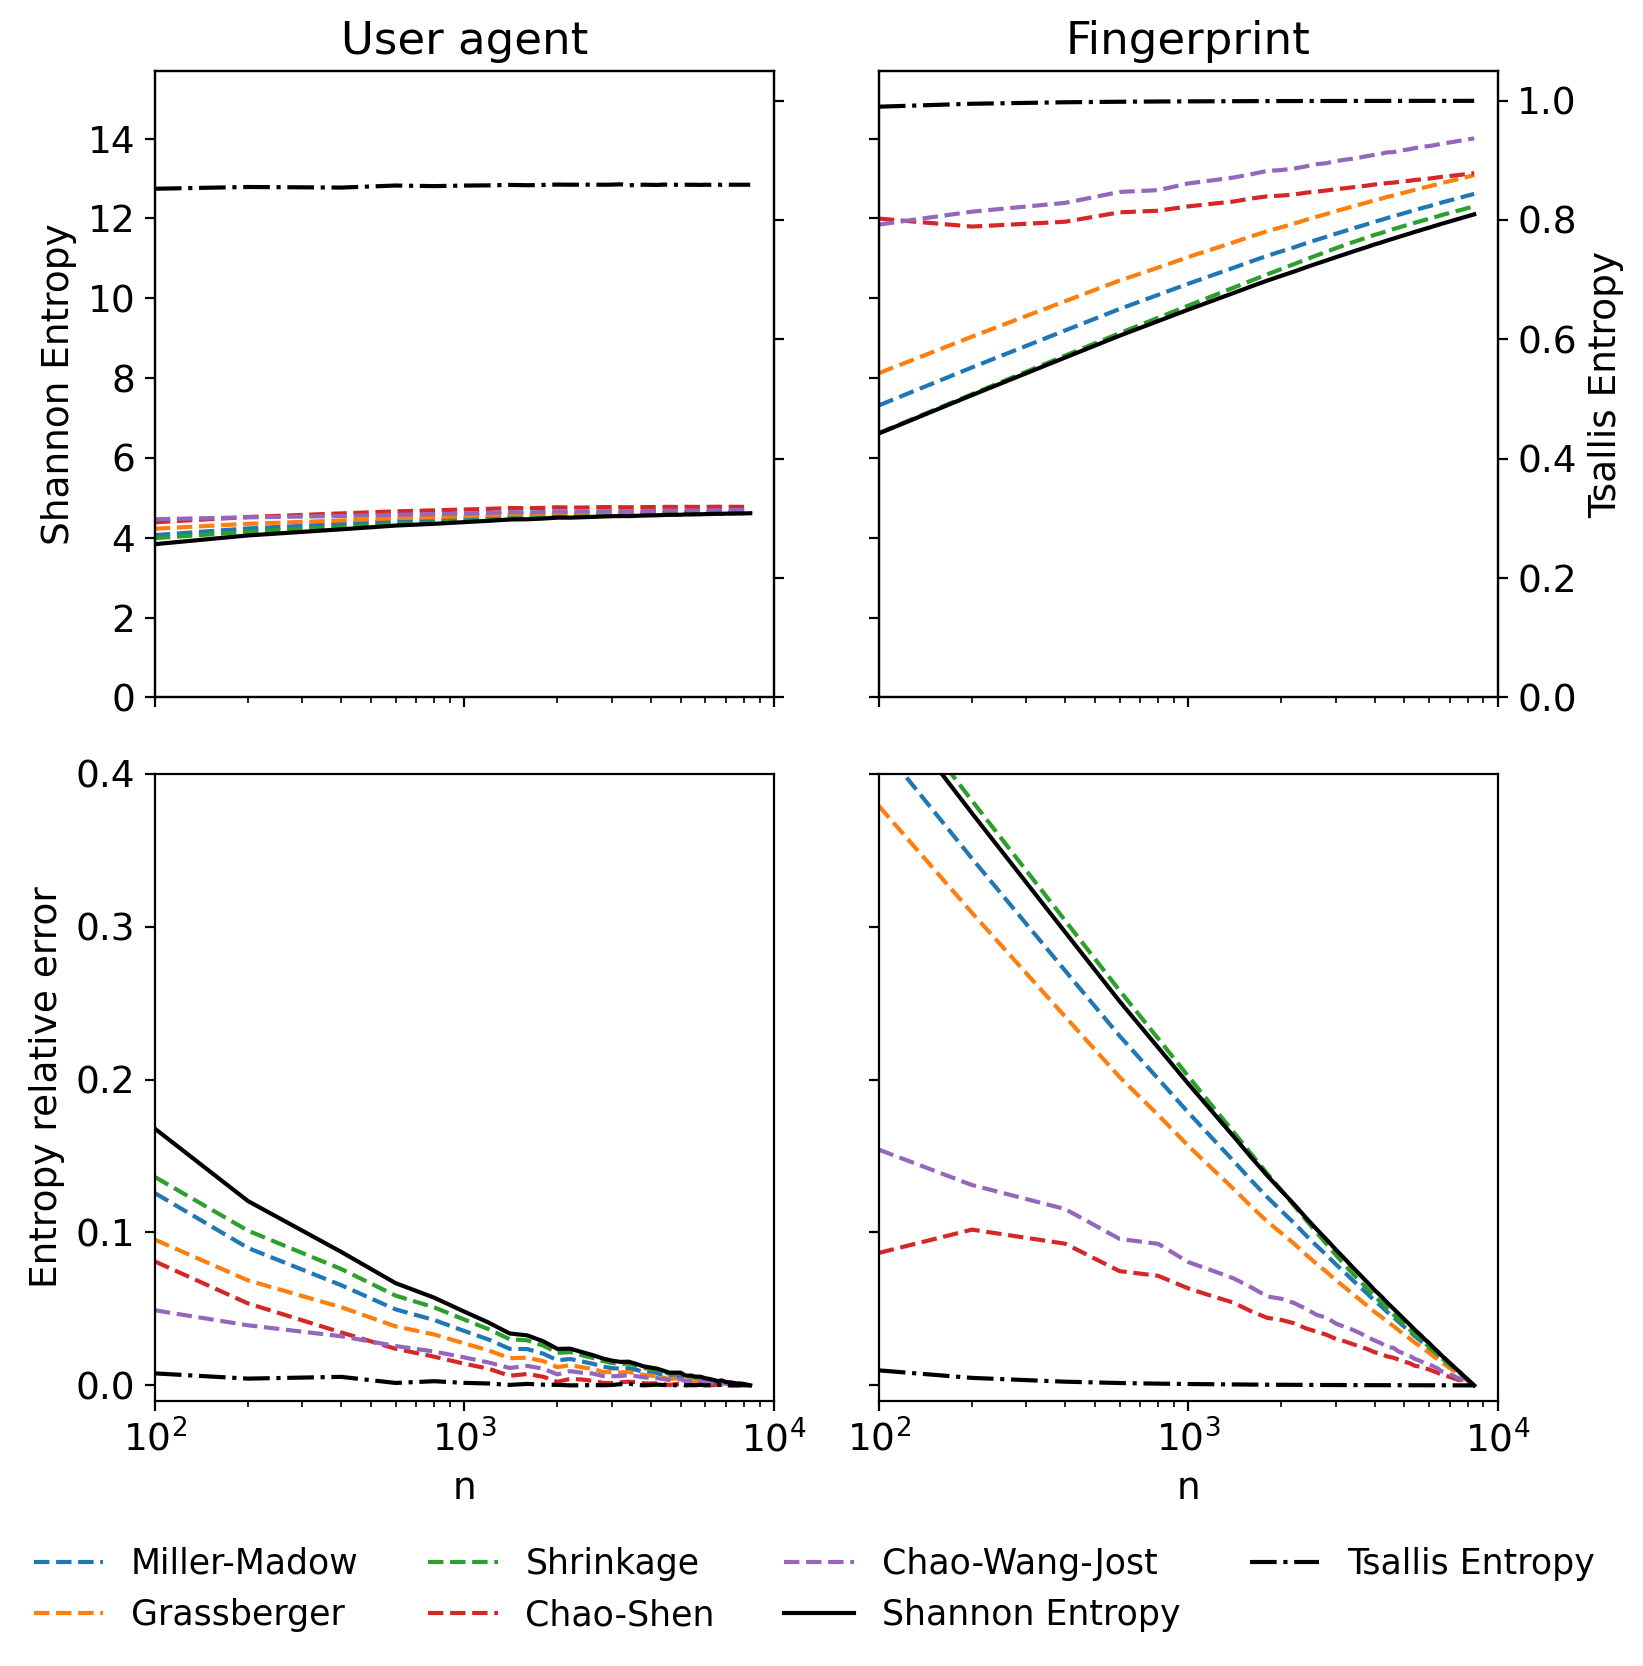

In [ ]:
generate_plot(
    attributes_entropy_data,
    plot_attributes=['User agent', 'Fingerprint'],
    logscale=True
)